Dataset Shape: (7043, 21)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Train Shape: (4930, 19)
Validation Shape: (1056, 19)
Test Shape: (1057, 19)
Logistic Regression Best Params: {'C': 0.01, 'solver': 'liblinear'}
              precision    recall  f1-score      support
0              0.837545  0.896907  0.866210   776.000000
1              0.646018  0.519573  0.575937   281.000000
accuracy       0.796594  0.796594  0.796594     0.796594
macro avg      0.741781  0.708240  0.721074  1057.000000
weighted avg   0.786628  0.796594  0.789042  1057.000000


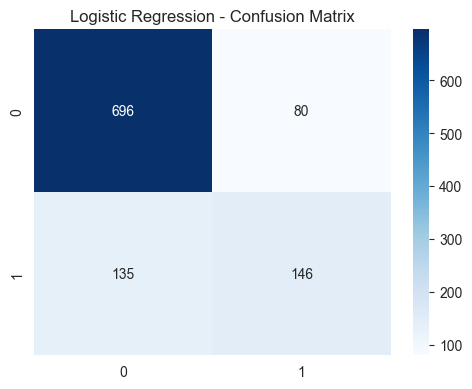

Decision Tree Best Params: {'max_depth': 5, 'min_samples_split': 5}
              precision    recall  f1-score     support
0              0.853015  0.875000  0.863868   776.00000
1              0.628352  0.583630  0.605166   281.00000
accuracy       0.797540  0.797540  0.797540     0.79754
macro avg      0.740684  0.729315  0.734517  1057.00000
weighted avg   0.793289  0.797540  0.795093  1057.00000


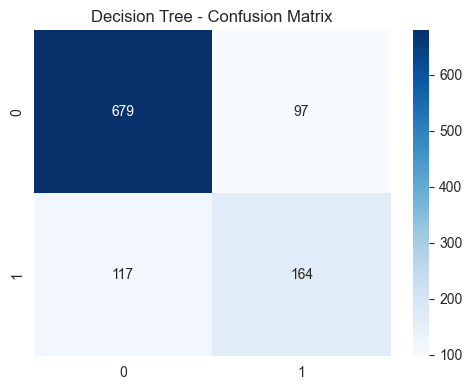

Random Forest Best Params: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score      support
0              0.826901  0.911082  0.866953   776.000000
1              0.658416  0.473310  0.550725   281.000000
accuracy       0.794702  0.794702  0.794702     0.794702
macro avg      0.742658  0.692196  0.708839  1057.000000
weighted avg   0.782109  0.794702  0.782885  1057.000000


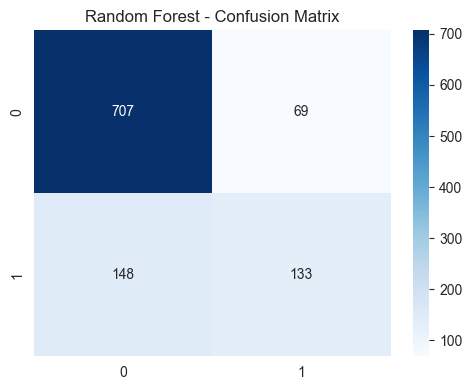

SVM Best Params: {'C': 1, 'kernel': 'linear'}
              precision    recall  f1-score      support
0              0.826446  0.902062  0.862600   776.000000
1              0.638095  0.476868  0.545825   281.000000
accuracy       0.789026  0.789026  0.789026     0.789026
macro avg      0.732271  0.689465  0.704212  1057.000000
weighted avg   0.776374  0.789026  0.778386  1057.000000


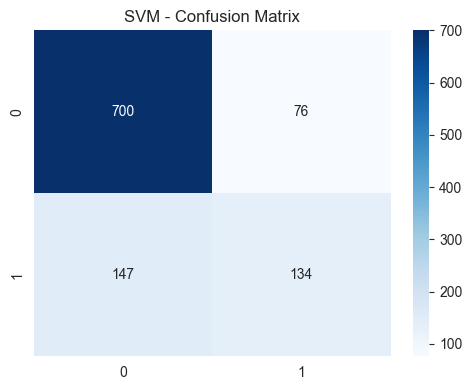

KNN Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
              precision    recall  f1-score      support
0              0.821208  0.858247  0.839319   776.000000
1              0.552846  0.483986  0.516129   281.000000
accuracy       0.758751  0.758751  0.758751     0.758751
macro avg      0.687027  0.671117  0.677724  1057.000000
weighted avg   0.749865  0.758751  0.753400  1057.000000


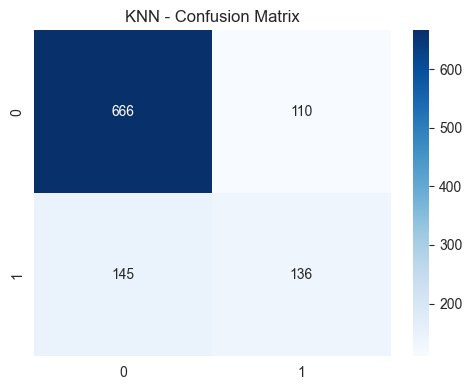

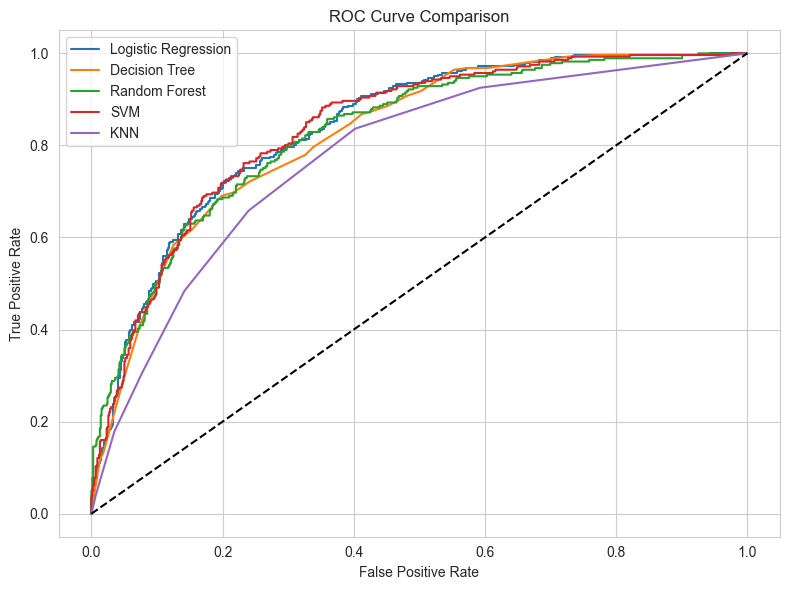

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time
0,Logistic Regression,0.796594,0.646018,0.519573,0.575937,0.838037,7.736719
3,SVM,0.789026,0.638095,0.476868,0.545825,0.837934,44.064139
2,Random Forest,0.794702,0.658416,0.473310,0.550725,0.828179,7.697855
1,Decision Tree,0.797540,0.628352,0.583630,0.605166,0.823442,0.998367
4,KNN,0.758751,0.552846,0.483986,0.516129,0.776216,1.201282


Best Model: Logistic Regression


In [7]:
# ============================================================
# Task 3 — Classification: Churn Prediction
# Build and evaluate classifiers one-by-one
# ============================================================
import sys
import os
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(os.path.abspath(".."))
from src.utils import save_figure
from src.classification import (
    prepare_classification_data,
    run_classification_model,
    get_classification_models,
    get_feature_importance
)

sns.set_style("whitegrid")


# ============================================================
# Section 1 — Load Dataset
# ============================================================
df = pd.read_csv("../data/processed/telco_cleaned.csv")

print("Dataset Shape:", df.shape)
display(df.head())


# ============================================================
# Section 2 — Prepare Classification Data
# ============================================================
(
    X_train, X_val, X_test,
    X_train_scaled, X_val_scaled, X_test_scaled,
    y_train, y_val, y_test
) = prepare_classification_data(df)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)


# ============================================================
# Section 3 — Load Model Configurations
# ============================================================
models = get_classification_models()
results = []
roc_curves = {}
trained_models = {}


# ============================================================
# Section 4 — Train Models One-by-One
# ============================================================

# ------------------------------------------------------------
# 4.1 Logistic Regression
# ------------------------------------------------------------
model, param_grid = models["Logistic Regression"]

log_model, log_pred, log_metrics = run_classification_model(
    "Logistic Regression",
    model,
    param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append({
    "Model": log_metrics["Model"],
    "Accuracy": log_metrics["Accuracy"],
    "Precision": log_metrics["Precision"],
    "Recall": log_metrics["Recall"],
    "F1": log_metrics["F1"],
    "ROC_AUC": log_metrics["ROC_AUC"],
    "Training_Time": log_metrics["Training_Time"]
})

roc_curves["Logistic Regression"] = (log_metrics["FPR"], log_metrics["TPR"])
trained_models["Logistic Regression"] = log_model

print("Logistic Regression Best Params:", log_metrics["Best_Params"])
print(pd.DataFrame(log_metrics["Classification_Report"]).transpose())

plt.figure(figsize=(5, 4))
sns.heatmap(log_metrics["Confusion_Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
save_figure("../reports/figures/logistic_confusion_matrix.png")
plt.show()


# ------------------------------------------------------------
# 4.2 Decision Tree
# ------------------------------------------------------------
model, param_grid = models["Decision Tree"]

dt_model, dt_pred, dt_metrics = run_classification_model(
    "Decision Tree",
    model,
    param_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

results.append({
    "Model": dt_metrics["Model"],
    "Accuracy": dt_metrics["Accuracy"],
    "Precision": dt_metrics["Precision"],
    "Recall": dt_metrics["Recall"],
    "F1": dt_metrics["F1"],
    "ROC_AUC": dt_metrics["ROC_AUC"],
    "Training_Time": dt_metrics["Training_Time"]
})

roc_curves["Decision Tree"] = (dt_metrics["FPR"], dt_metrics["TPR"])
trained_models["Decision Tree"] = dt_model

print("Decision Tree Best Params:", dt_metrics["Best_Params"])
print(pd.DataFrame(dt_metrics["Classification_Report"]).transpose())

plt.figure(figsize=(5, 4))
sns.heatmap(dt_metrics["Confusion_Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
save_figure("../reports/figures/decision_tree_confusion_matrix.png")
plt.show()


# ------------------------------------------------------------
# 4.3 Random Forest
# ------------------------------------------------------------
model, param_grid = models["Random Forest"]

rf_model, rf_pred, rf_metrics = run_classification_model(
    "Random Forest",
    model,
    param_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

results.append({
    "Model": rf_metrics["Model"],
    "Accuracy": rf_metrics["Accuracy"],
    "Precision": rf_metrics["Precision"],
    "Recall": rf_metrics["Recall"],
    "F1": rf_metrics["F1"],
    "ROC_AUC": rf_metrics["ROC_AUC"],
    "Training_Time": rf_metrics["Training_Time"]
})

roc_curves["Random Forest"] = (rf_metrics["FPR"], rf_metrics["TPR"])
trained_models["Random Forest"] = rf_model

print("Random Forest Best Params:", rf_metrics["Best_Params"])
print(pd.DataFrame(rf_metrics["Classification_Report"]).transpose())

plt.figure(figsize=(5, 4))
sns.heatmap(rf_metrics["Confusion_Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
save_figure("../reports/figures/random_forest_confusion_matrix.png")
plt.show()


# ------------------------------------------------------------
# 4.4 SVM
# ------------------------------------------------------------
model, param_grid = models["SVM"]

svm_model, svm_pred, svm_metrics = run_classification_model(
    "SVM",
    model,
    param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append({
    "Model": svm_metrics["Model"],
    "Accuracy": svm_metrics["Accuracy"],
    "Precision": svm_metrics["Precision"],
    "Recall": svm_metrics["Recall"],
    "F1": svm_metrics["F1"],
    "ROC_AUC": svm_metrics["ROC_AUC"],
    "Training_Time": svm_metrics["Training_Time"]
})

roc_curves["SVM"] = (svm_metrics["FPR"], svm_metrics["TPR"])
trained_models["SVM"] = svm_model

print("SVM Best Params:", svm_metrics["Best_Params"])
print(pd.DataFrame(svm_metrics["Classification_Report"]).transpose())

plt.figure(figsize=(5, 4))
sns.heatmap(svm_metrics["Confusion_Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("SVM - Confusion Matrix")
save_figure("../reports/figures/svm_confusion_matrix.png")
plt.show()


# ------------------------------------------------------------
# 4.5 KNN
# ------------------------------------------------------------
model, param_grid = models["KNN"]

knn_model, knn_pred, knn_metrics = run_classification_model(
    "KNN",
    model,
    param_grid,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append({
    "Model": knn_metrics["Model"],
    "Accuracy": knn_metrics["Accuracy"],
    "Precision": knn_metrics["Precision"],
    "Recall": knn_metrics["Recall"],
    "F1": knn_metrics["F1"],
    "ROC_AUC": knn_metrics["ROC_AUC"],
    "Training_Time": knn_metrics["Training_Time"]
})

roc_curves["KNN"] = (knn_metrics["FPR"], knn_metrics["TPR"])
trained_models["KNN"] = knn_model

print("KNN Best Params:", knn_metrics["Best_Params"])
print(pd.DataFrame(knn_metrics["Classification_Report"]).transpose())

plt.figure(figsize=(5, 4))
sns.heatmap(knn_metrics["Confusion_Matrix"], annot=True, fmt="d", cmap="Blues")
plt.title("KNN - Confusion Matrix")
save_figure("../reports/figures/knn_confusion_matrix.png")
plt.show()


# ============================================================
# Section 5 — ROC Curve Comparison
# ============================================================
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr) in roc_curves.items():
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
save_figure("../reports/figures/roc_curve_comparison.png")
plt.show()


# ============================================================
# Section 6 — Final Comparison Table
# ============================================================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("ROC_AUC", ascending=False)

display(results_df)

results_df.to_csv("../artifacts/classification_results.csv", index=False)


# ============================================================
# Section 7 — Best Model Selection
# ============================================================
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)


# ============================================================
# Section 8 — Feature Importance (Best Model)
# ============================================================
if best_model_name in ["Decision Tree", "Random Forest"]:
    fi = get_feature_importance(best_model, X_train.columns)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi.head(10), x="Importance", y="Feature")
    plt.title(f"{best_model_name} - Top 10 Feature Importances")
    save_figure("../reports/figures/best_model_feature_importance.png")
    plt.show()

In [8]:
import joblib

joblib.dump(best_model, "../artifacts/best_classifier.pkl")

print("Best model saved successfully!")

Best model saved successfully!
